# Detección de Anomalías por Error de Reconstrucción (PCA)


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/16_anomalias_por_reconstruccion_pca.ipynb)

## Objetivos


- Cambiar el paradigma de modelado: de buscar patrones comunes (Clustering/Clasificación) a cazar excepciones (Detección de Anomalías).
- Utilizar el **Error de Reconstrucción de PCA** como una métrica no supervisada para identificar valores atípicos.
- **Criterio de Ingeniería:** Discutir y contrastar estrategias para definir el umbral de anomalía (Media + 3 STD vs. Percentiles/Contaminación) frente a distribuciones asimétricas reales.



## Prerrequisitos


- Comprensión de PCA como algoritmo de compresión con pérdida.
- Haber completado: [Reducción de Dimensionalidad: PCA y Reconstrucción](11_pca_y_reconstruccion.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## Introducción Teórica


Imaginemos que trabajamos en el departamento de ciberseguridad de un banco. Tenemos un dataset con `100.000` transacciones;` 99.800` son normales y solo `200` son fraudes.

Si intentamos usar un modelo de Clasificación Supervisada (como Random Forest) y no aplicamos técnicas avanzadas de balanceo, el modelo aprenderá una regla muy simple: *"Predecir siempre que la transacción es Normal"*. Obtendremos un modelo con **99,8% de Accuracy**, pero dejaremos pasar todos los fraudes. El modelo es matemáticamente excelente, pero inútil para el negocio.

Además, los fraudes mutan. Los estafadores inventan nuevas técnicas cada día. Un modelo supervisado solo puede detectar los fraudes que ya ha visto en el pasado.

### El Enfoque No Supervisado: Aprender la "Normalidad"



La Detección de Anomalías invierte el problema. En lugar de intentar aprender cómo es un fraude, **aprende exclusivamente cómo es una transacción normal**. Todo lo que se desvíe de esa "normalidad" se marca como sospechoso.

Para ello, utilizaremos el **Error de Reconstrucción de PCA** que vimos en el notebook [Reducción de Dimensionalidad: PCA y Reconstrucción](11_pca_y_reconstruccion.ipynb).

**La Intuición (La Analogía del MP3, otra vez...):**  
Si entrenamos un algoritmo de compresión (*MP... 4, la mejora*) escuchando *únicamente* música clásica, el algoritmo aprenderá a comprimir y descomprimir violines y pianos a la perfección. Pero si de repente le pasamos una canción de *Heavy Metal*, el algoritmo no sabrá cómo procesar las guitarras distorsionadas. Al intentar descomprimirla, el sonido será un desastre. **El error de reconstrucción será altísimo.**

En nuestro caso, PCA aprenderá el subespacio (las componentes principales) donde viven las transacciones normales. Cuando llegue un fraude, al no pertenecer a ese subespacio, se proyectará mal y su error de reconstrucción se disparará. La idea, es usar este conceptos a nuestro favor...

A continuación, una ilustración de esto. Visualmente queda claro que, el punto "débil" del algoritmo, lo usamos como gancho para la detección de los anómalos/*outliers*.

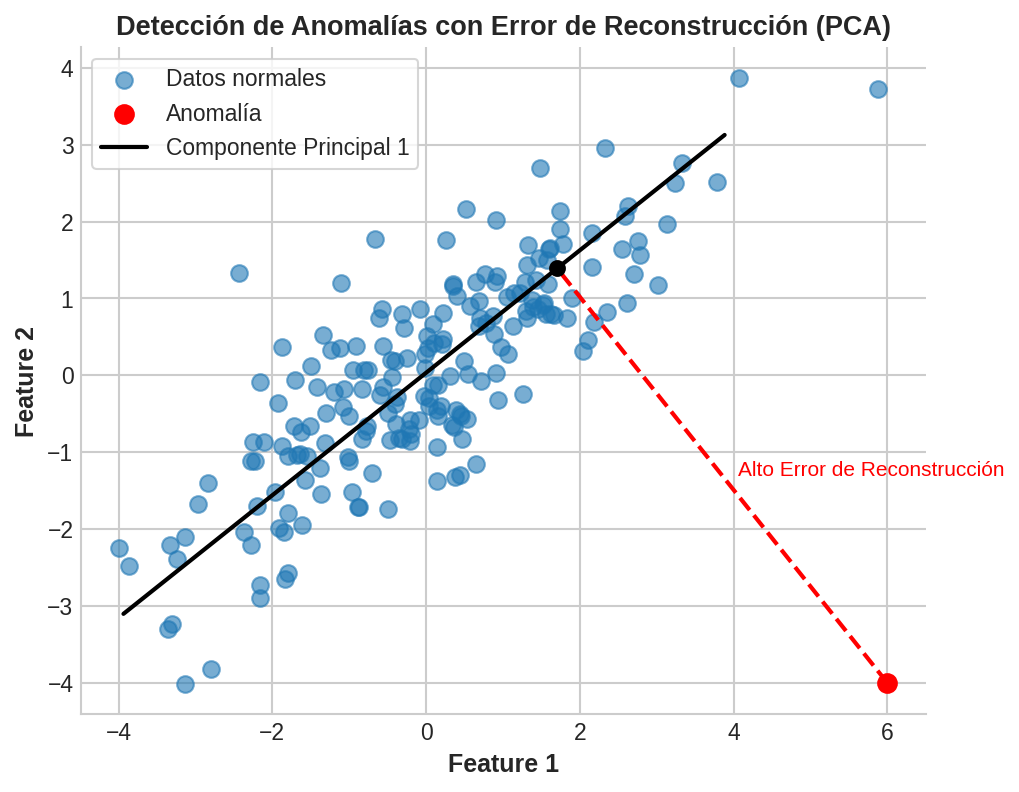

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generar datos normales (elipse inclinada)
np.random.seed(42)

mean = [0, 0]
cov = [[3, 2], [2, 2]]  # genera forma elíptica diagonal
X = np.random.multivariate_normal(mean, cov, 200)

# -------------------------
# Ajustar PCA (1 componente)
# -------------------------
pca = PCA(n_components=1)
pca.fit(X)

# Dirección principal
pc1 = pca.components_[0]
center = pca.mean_

# -------------------------
# Definir anomalía
# -------------------------
anomaly = np.array([[6, -4]])

# -------------------------
# Proyección de la anomalía sobre PC1
# -------------------------
# fórmula de proyección
proj_length = np.dot(anomaly - center, pc1)
projection = center + proj_length * pc1

# -------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(7, 6))

# Datos normales
ax.scatter(X[:, 0], X[:, 1],
           color='#1f77b4',
           alpha=0.6,
           label='Datos normales')

# Anomalía
ax.scatter(anomaly[:, 0], anomaly[:, 1],
           color='red',
           s=80,
           label='Anomalía',
           zorder=5)

# Línea de PC1
line_range = np.linspace(-5, 5, 100)
line = center + np.outer(line_range, pc1)

ax.plot(line[:, 0], line[:, 1],
        color='black',
        linewidth=2,
        label='Componente Principal 1')

# Proyección (línea punteada)
ax.plot([anomaly[0, 0], projection[0]],
        [anomaly[0, 1], projection[1]],
        linestyle='--',
        color='red',
        linewidth=2)

# Punto proyectado
ax.scatter(projection[0], projection[1],
           color='black',
           s=50,
           zorder=6)

# Etiqueta del error
mid_x = (anomaly[0, 0] + projection[0]) / 2
mid_y = (anomaly[0, 1] + projection[1]) / 2

ax.text(mid_x + 0.2, mid_y,
        'Alto Error de Reconstrucción',
        fontsize=10,
        color='red')

ax.set_title('Detección de Anomalías con Error de Reconstrucción (PCA)', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')

ax.legend(frameon=True)
ax.set_aspect('equal')

# Bordes limpios
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a utilizar el famoso **Credit Card Fraud Dataset**. Para agilizar el cómputo en este notebook, trabajamos con una pequeña muestra representativa.

*Nota de Ingeniería:* En un entorno ideal, entrenaríamos el PCA *solo* con datos normales. Sin embargo, en la vida real rara vez tenemos un dataset 100% limpio. Entrenamos el PCA con todo el dataset, asumiendo que como los fraudes son tan raros (baja contaminación), no tendrán la fuerza suficiente para desviar las componentes principales. Es decir, ahora el "gran desbalance" juega a favor.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carga de datos
dataset_path = "datasets/ccf/creditcard_sample.csv"

df = load_dataset(dataset_path)

# Separamos Features y Target (El Target 'Class' SOLO lo usaremos al final para evaluar)
# Vamos por el camino full NO SUPERVISADO
X = df.drop(columns=['Class', 'Time'], errors='ignore')
y_true = df['Class']

print(f"Transacciones totales: {len(df)}")
print(f"Fraudes reales: {sum(y_true == 1)} ({(sum(y_true == 1)/len(df))*100:.2f}% de contaminación)")

# 2. Estandarización (Obligatorio para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Entrenamos PCA (Retenemos un % de la varianza, ej. 80%)
# Al no retener el 100%, forzamos al modelo a perder información (el ruido y las anomalías)
pca = PCA(n_components=0.80, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 4. Reconstruimos los datos
X_reconstruido = pca.inverse_transform(X_pca)

# 5. Calculamos el Error de Reconstrucción (MSE por cada fila)
# Promedio de las diferencias al cuadrado entre las variables originales y las reconstruidas
errores_reconstruccion = np.mean((X_scaled - X_reconstruido)**2, axis=1)

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/ccf/creditcard_sample.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 10000 filas y 31 columnas.
Transacciones totales: 10000
Fraudes reales: 17 (0.17% de contaminación)


### El Reto de Ingeniería: ¿Dónde trazamos la línea?



Tenemos un array con `10.000` números (los errores de reconstrucción). Sabemos que los números más grandes probablemente sean fraudes. Pero, **¿a partir de qué número exacto disparamos la alarma del banco?**

Vamos a visualizar la distribución de estos errores:

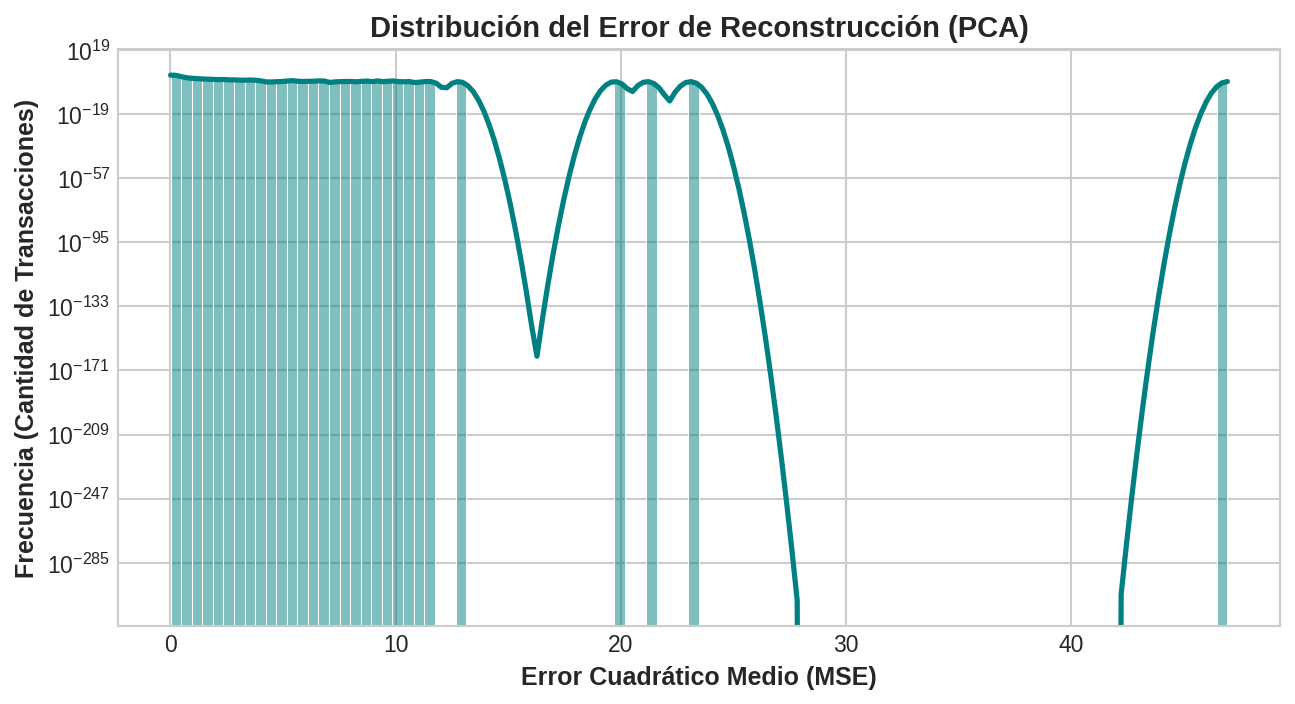

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(errores_reconstruccion, bins=100, kde=True, color='teal')
plt.title("Distribución del Error de Reconstrucción (PCA)")
plt.xlabel("Error Cuadrático Medio (MSE)")
plt.ylabel("Frecuencia (Cantidad de Transacciones)")
plt.yscale('log') # Escala logarítmica porque la mayoría de los errores son cercanos a cero
plt.show()

Observar el gráfico. La inmensa mayoría de las transacciones tienen un error cercano a 0. Pero hay una larga "cola" hacia la derecha con errores que llegan a más de 40.

#### Estrategia 1: El Enfoque Estadístico Clásico (Media + 3 STD)


La regla empírica de la estadística dice que si los datos siguen una distribución normal (Campana de Gauss), el `99,7%` de los datos caerán dentro de 3 Desviaciones Estándar (STD) de la media. Todo lo que esté por encima, es una anomalía.

**⚠️ Alerta de Supuesto Falso:**
Mirar el histograma de nuevo. **No es una campana de Gauss.** Es una distribución fuertemente asimétrica hacia la derecha. Aplicar Media + 3 STD aquí es un error conceptual grave, porque la media y la desviación estándar se ven arrastradas artificialmente por esos mismos valores extremos que intentamos detectar.

#### Estrategia 2: El Enfoque de Negocio (Percentiles y Contaminación)


En la ingeniería aplicada, el umbral rara vez lo dicta la matemática pura; lo dicta el **presupuesto operativo del negocio**.

Si el equipo de analistas de fraude del banco solo tiene capacidad humana para revisar 100 transacciones al día, no sirve de nada que tu modelo marque `5.000` transacciones como anómalas.

Definimos la **Contaminación** como el porcentaje de anomalías que el negocio *espera* o *puede gestionar*. Si asumimos una contaminación del 2%, trazamos nuestro umbral exactamente en el **Percentil 98** de nuestros errores.

Umbral Estadístico (Media + 3 STD): 2.5856
Umbral de Negocio (Percentil 98):   1.0595


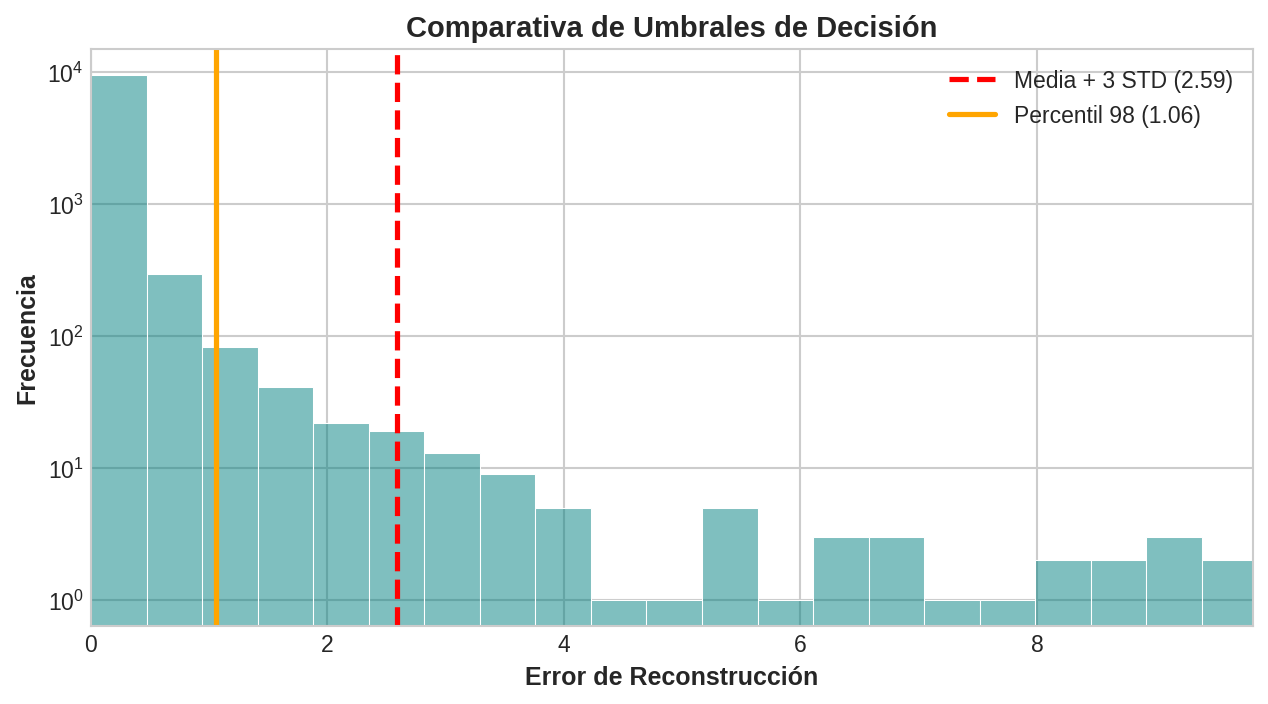

In [6]:
# Calculamos umbrales
umbral_estadistico = np.mean(errores_reconstruccion) + 3 * np.std(errores_reconstruccion)

# Asumimos que el negocio nos permite investigar el 2% de las transacciones más raras
contaminacion_esperada = 0.02
umbral_percentil = np.percentile(errores_reconstruccion, 100 * (1 - contaminacion_esperada))

print(f"Umbral Estadístico (Media + 3 STD): {umbral_estadistico:.4f}")
print(f"Umbral de Negocio (Percentil 98):   {umbral_percentil:.4f}")

# Visualizamos los umbrales en la cola de la distribución
plt.figure(figsize=(10, 5))
sns.histplot(errores_reconstruccion, bins=100, color='teal', alpha=0.5)
plt.axvline(umbral_estadistico, color='red', linestyle='--', label=f'Media + 3 STD ({umbral_estadistico:.2f})')
plt.axvline(umbral_percentil, color='orange', linestyle='-', label=f'Percentil 98 ({umbral_percentil:.2f})')
plt.title("Comparativa de Umbrales de Decisión")
plt.xlabel("Error de Reconstrucción")
plt.ylabel("Frecuencia")
plt.yscale('log')
plt.xlim(0, np.percentile(errores_reconstruccion, 99.9)) # Zoom a la zona crítica
plt.legend()
plt.show()

### Evaluando el Sistema



Vamos a utilizar el Umbral de Negocio (Percentil 98) para clasificar las transacciones. Si el error es mayor al umbral, predecimos `1` (Fraude). Si es menor, predecimos `0` (Normal). Notar que definimos "las etiquetas", utilizando justamente una única variable de salida; "el error de reconstrucción".

Como en este dataset de laboratorio *sí* tenemos las etiquetas reales (`y_true`), podemos ver qué tan bien funcionó nuestra lógica no supervisada.

--- Reporte de Detección de Fraude (No Supervisado) ---
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99      9983
  Fraude (1)       0.06      0.65      0.10        17

    accuracy                           0.98     10000
   macro avg       0.53      0.81      0.55     10000
weighted avg       1.00      0.98      0.99     10000



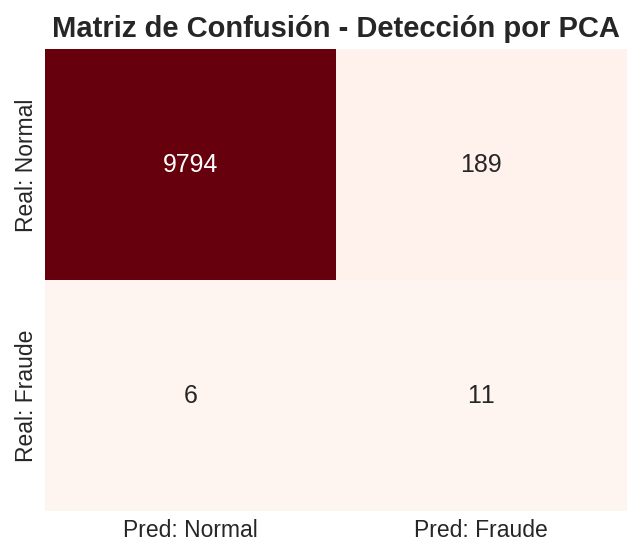

In [7]:
# Clasificamos basados en el umbral de negocio
y_pred_anomalia = (errores_reconstruccion >= umbral_percentil).astype(int)

# Evaluamos
print("--- Reporte de Detección de Fraude (No Supervisado) ---")
print(classification_report(y_true, y_pred_anomalia, target_names=['Normal (0)', 'Fraude (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred_anomalia)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Fraude'],
            yticklabels=['Real: Normal', 'Real: Fraude'])
plt.title("Matriz de Confusión - Detección por PCA")
plt.show()

## Resultados y Discusión


Analizar la Matriz de Confusión. ¡Es un resultado "excelente" para un modelo que **nunca vio una etiqueta de fraude durante su entrenamiento**!

**Encontramos 11 de 17 fraudes**. Pero *revisamos 189* casos que el sistema marcó como anómalos, pero no eran fraude (trabajo manual para el personal). El umbral elegido, mueve estos valores.


1. **Verdaderos Positivos (Abajo a la derecha):** El modelo logró atrapar una gran porción (11/17) de los fraudes reales simplemente notando que "no encajaban" en la estructura matemática de las transacciones normales.
2. **Falsos Positivos (Arriba a la derecha):** El modelo marcó varias transacciones normales como fraude (189). ¿Es esto un error? No necesariamente. Estas transacciones normales probablemente eran compras extremadamente raras (ej. un cliente comprando un barco a las 3 AM en otro país). Matemáticamente *son* anomalías, aunque legalmente no sean un fraude.
3. **El Poder del Umbral:** Si el banco quiere atrapar *todos* los fraudes (reducir Falsos Negativos a cero), simplemente debemos bajar el umbral (ej. al Percentil 90). A cambio, el equipo de analistas tendrá que revisar miles de Falsos Positivos. **El Machine Learning no toma esta decisión; la toma el Director de Riesgos.**

## Conexiones y Próximos Pasos



Construimos un detector de anomalías "artesanal" utilizando PCA y calculando los umbrales a mano. Sin embargo, PCA sigue siendo un modelo lineal. Si las transacciones normales forman topologías complejas, PCA generará muchos falsos positivos.

- ➡️ **Siguiente:** En el notebook [Isolation Forest y LOF](17_isolation_forest_y_lof.ipynb), dejamos de hacer el trabajo manual. Procedemos a conocer algoritmos diseñados *específicamente* para cazar anomalías en alta dimensionalidad, que integran el concepto de `contamination` de forma nativa en su código y manejan relaciones no lineales sin esfuerzo.
- 🔄 **Relacionado:** Si se quiere entender cómo la asimetría de los datos afecta a la media y la desviación estándar, repasar notebooks del capítulo de EDA. Quizá ahora, se entienda mejor el de [Detección Avanzada de Anomalías y Ruido](../02_eda/07_deteccion_avanzada_anomalias.ipynb) .

## Referencias


1. Chandola, V., Banerjee, A., & Kumar, V. (2009). *Anomaly detection: A survey*. ACM computing surveys (CSUR), 41(3), 1-58. [Anomaly Detection: A Survey](https://dl.acm.org/doi/epdf/10.1145/1541880.1541882)
2. [Scikit-Learn: Novelty and Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html)

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
